## Random Forest Classifier

In this part we classify the deposits with a random forest: classification trees grown on bootstrap samples of the deposits, where each split only considers a random subset of the inputs (`max_features`), and which vote for the label. As in `1B3_random_forest`, averaging many decorrelated trees reduces the variance of a single tree, which overfits its training deposits (see the classification tree notebook). The deposits, their inputs and their label are those of the naive Bayes notebook (`deposit_data`).

### Main observations

- **Number of trees:** The validation F1 is noisy (from 0.63 to 0.75) and has no clear trend from 25 trees on: with 32 to 37 deposits per fold, a single deposit moves the F1 of a fold by about 0.03. 200 trees are kept, as in `1B`.
- **Hyperparameters:** Fully grown trees are the best (`min_samples_leaf = 1`), and `max_features` changes little (0.72 to 0.75), with 0.1 as best value: 3 of the 32 inputs drawn at each split.
- **Results:** F1 of 0.75 and recall of 0.69 (nested F1 of 0.70), barely above the single classification tree (0.72) and at the level of the regression random forest of `1B3` (0.76 and 0.64). The forest is cautious: only 12 false alarms, but 26 of the 83 non-conforming deposits missed.
- **Threshold:** Its probabilities are informative. Declaring non-conforming every deposit with a probability of 0.4 or more, instead of 0.5, raises the recall to 0.83 and the F1 to 0.78. The threshold is left at 0.5 in `results.csv`, the default decision rule of every classifier.

### Operations in order

1. Load the train set with `load_train` and the labelled deposits with `get_deposit_xy`.
2. Plot the train and validation F1 against the number of trees, to fix `n_estimators`.
3. Tune `max_features` and `min_samples_leaf` by a grid search on the folds of `helpers/utils.py`, with the F1 on the non-conforming deposits as score.
4. Evaluate the best model with `evaluate_label`, and compute the F1 and the recall for other thresholds of its probability.
5. Check its F1 by nested cross-validation.
6. Save it to `results.csv` and compare it with the other models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, validation_curve

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, load_train, get_deposit_xy, build_pipeline,
    oof_predict_label, nested_oof_predict_label, evaluate_label, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()
X, y, cv = get_deposit_xy(train)

print(X.shape, "| non-conforming:", y.sum())

(175, 32) | non-conforming: 83


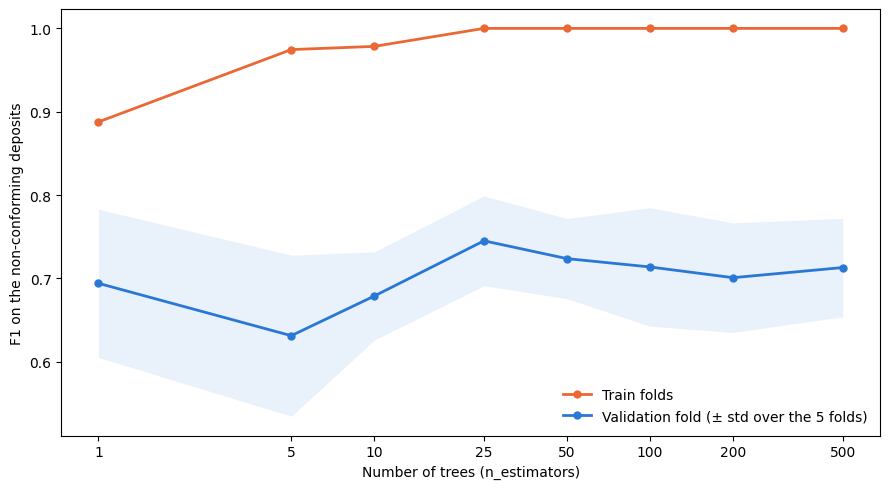

,train_F1,validation_F1,validation_F1_std
n_estimators,,,
1,0.888,0.694,0.089
5,0.975,0.631,0.097
10,0.978,0.679,0.053
25,1.000,0.745,0.054
50,1.000,0.724,0.048
100,1.000,0.714,0.071
200,1.000,0.701,0.066
500,1.000,0.713,0.059


In [4]:
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]

train_scores, val_scores = validation_curve(
    build_pipeline(RandomForestClassifier(random_state=SEED)),
    X, y,
    param_name="model__n_estimators",
    param_range=n_trees,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
curve = pd.DataFrame({"train_F1": train_scores.mean(axis=1), "validation_F1": val_scores.mean(axis=1), "validation_F1_std": val_scores.std(axis=1)}, index=pd.Index(n_trees, name="n_estimators"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(n_trees, curve["validation_F1"] - curve["validation_F1_std"], curve["validation_F1"] + curve["validation_F1_std"], color="#2a78d6", alpha=0.1, linewidth=0)
ax.plot(n_trees, curve["train_F1"], color="#eb6834", linewidth=2, marker="o", markersize=5, label="Train folds")
ax.plot(n_trees, curve["validation_F1"], color="#2a78d6", linewidth=2, marker="o", markersize=5, label="Validation fold (± std over the 5 folds)")
ax.set_xscale("log")
ax.set_xticks(n_trees, n_trees)
ax.minorticks_off()
ax.set_xlabel("Number of trees (n_estimators)")
ax.set_ylabel("F1 on the non-conforming deposits")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

curve.round(3)

`validation_curve` fits the forest on the train folds for each number of trees, with the default `max_features` of the classifier (the square root of the number of inputs, 5 of the 32 at each split), and gives the F1 on the train and validation folds.

- **Train folds:** 0.89 with a single tree grown on a bootstrap sample, and 1 from 25 trees on: the vote of fully grown trees learns the training deposits by heart.
- **Validation fold:** Between 0.63 and 0.75, without a clear trend from 25 trees on (0.70 to 0.75), with a standard deviation of 0.05 to 0.10 over the folds. Unlike the MAE of `1B`, the F1 of 32 to 37 deposits changes by about 0.03 when a single deposit changes class, so the curve is noisy. 200 trees are kept, as for the ensembles of `1B`.

In [5]:
param_grid = {"model__max_features": [0.1, 0.2, 0.33, 0.5, 0.75, 1.0], "model__min_samples_leaf": [1, 2, 4, 8]}

search = GridSearchCV(
    build_pipeline(RandomForestClassifier(n_estimators=200, random_state=SEED)),
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
).fit(X, y)

pd.DataFrame(search.cv_results_).pivot(index="param_model__min_samples_leaf", columns="param_model__max_features", values="mean_test_score").rename_axis(index="min_samples_leaf", columns="max_features").round(3)

max_features,0.10,0.20,0.33,0.50,0.75,1.00
min_samples_leaf,,,,,,
1,0.748,0.717,0.740,0.740,0.737,0.732
2,0.713,0.711,0.727,0.716,0.726,0.729
4,0.703,0.691,0.682,0.686,0.669,0.681
8,0.632,0.677,0.649,0.632,0.610,0.619


The validation F1 of each pair (`min_samples_leaf`, `max_features`), with 200 trees, on the grid of `1B3`.

- **min_samples_leaf:** The F1 goes down when the leaves get larger, from 0.72-0.75 with 1 deposit per leaf to 0.61-0.68 with 8. As in `1B3`, fully grown trees are the best, the vote of the trees is enough regularisation.
- **max_features:** With 1 deposit per leaf, between 0.72 and 0.75 for every value, 0.1 being the best (3 inputs drawn at each split). The gaps, 0.03 at most, are below the standard deviation over the folds. `max_features = 1.0` is the bagging of classification trees (0.73).

In [6]:
best = search.best_estimator_
print(search.best_params_, "validation F1:", round(search.best_score_, 3), "±", round(search.cv_results_["std_test_score"][search.best_index_], 3))

forest = evaluate_label("Random forest classifier", best, train)
display(forest.dropna(axis=1, how="all").round(2))

oof = oof_predict_label(best, train)
pd.DataFrame(confusion_matrix(y, oof["pred_nc"]), index=["conforming", "non-conforming"], columns=["predicted conforming", "predicted non-conforming"])

{'model__max_features': 0.1, 'model__min_samples_leaf': 1} validation F1: 0.748 ± 0.033


,model,target,family,n_clf,n_nc,F1_nc,recall_nc
0,Random forest classifier,label,all,175,83,0.75,0.69
1,Random forest classifier,label,C-Mn,161,79,0.78,0.71
2,Random forest classifier,label,CrMo2,8,1,0.00,0.00
3,Random forest classifier,label,CrMo91,6,3,0.29,0.33


,predicted conforming,predicted non-conforming
conforming,80,12
non-conforming,26,57


- **Best model:** `max_features = 0.1` and `min_samples_leaf = 1`, with a validation F1 of 0.75 ± 0.03.
- **All deposits:** F1 of 0.75 and recall of 0.69: 57 of the 83 non-conforming deposits are caught, for only 12 false alarms out of 92 (a precision of 0.83). Like the regression ensembles of `1B`, the forest misses non-conforming deposits rather than raising false alarms.
- **Per family:** The non-conforming CrMo2 deposit is missed, and 1 of the 3 non-conforming CrMo91 deposits is caught, with false alarms (F1 of 0.29).

In [7]:
thresholds = np.arange(0.2, 0.75, 0.05)
pd.DataFrame({
    "predicted_non_conforming": [(oof["score"] >= t).sum() for t in thresholds],
    "F1": [f1_score(y, oof["score"] >= t) for t in thresholds],
    "recall": [recall_score(y, oof["score"] >= t) for t in thresholds],
}, index=pd.Index(thresholds.round(2), name="threshold")).round(3)

,predicted_non_conforming,F1,recall
threshold,,,
0.20,146,0.707,0.976
0.25,134,0.719,0.940
0.30,126,0.708,0.892
0.35,110,0.725,0.843
0.40,95,0.775,0.831
0.45,83,0.771,0.771
0.50,70,0.745,0.687
0.55,60,0.727,0.627
0.60,57,0.714,0.602


The forest declares a deposit non-conforming when the share of its trees voting for it, the probability of `predict_proba`, is at least 0.5. The table gives the number of deposits declared non-conforming, the F1 and the recall for other thresholds, on the out-of-fold probabilities of `oof_predict_label`.

- **Lower threshold:** At 0.4, 95 deposits are declared non-conforming, and the recall rises to 0.83 and the F1 to 0.78. At 0.2, 98% of the non-conforming deposits are caught, but 146 of the 175 deposits are declared non-conforming (F1 of 0.71).
- **Use:** A classifier with probabilities lets the manufacturer choose the trade-off between missed bad welds and false alarms. The threshold of 0.4 is read here on the predictions it is scored on, so its F1 is optimistic: to be used, it should be tuned on the train folds like the other hyperparameters.

In [8]:
nested_pred, nested_params = nested_oof_predict_label(search, train)

print("Nested F1:", round(f1_score(y, nested_pred), 3), "| recall:", round(recall_score(y, nested_pred), 3))
nested_params

Nested F1: 0.697 | recall: 0.651


,max_features,min_samples_leaf
fold,,
0,0.10,1
1,0.10,1
2,0.33,1
3,1.00,1
4,1.00,2


The same nested cross-validation as in the other notebooks: the grid search is redone for each fold on the 4 other folds only.

- **Nested F1:** 0.70 and recall of 0.65, against 0.75 and 0.69. The chosen `max_features` goes from 0.1 to 1.0 depending on the fold: the grid is flat, and the best value on the 5 folds owes about 0.05 of F1 to luck.

In [9]:
results = save_results(forest)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees", "Naive Bayes classifier", "k-NN classifier", "SVM classifier", "Pruned tree classifier", "Random forest classifier"]
label = results[(results["target"] == "label") & results["model"].isin(models)]
label.pivot(index="model", columns="family", values=["F1_nc", "recall_nc"]).reindex(index=models).reindex(columns=["all", "C-Mn", "CrMo2", "CrMo91"], level="family").round(2)

F1_nc                    recall_nc                   
family                     all  C-Mn CrMo2 CrMo91       all  C-Mn CrMo2 CrMo91
model                                                                         
Baseline (mean)           0.00  0.00  0.00   0.00      0.00  0.00   0.0   0.00
Pruned CART               0.77  0.78  1.00   0.00      0.81  0.84   1.0   0.00
Bagging                   0.81  0.83  0.00   0.50      0.72  0.75   0.0   0.33
Random forest             0.76  0.77  0.00   0.50      0.64  0.66   0.0   0.33
Extra-Trees               0.84  0.85  0.00   0.80      0.72  0.73   0.0   0.67
Naive Bayes classifier    0.70  0.71  0.00   0.50      0.69  0.70   0.0   0.67
k-NN classifier           0.80  0.81  1.00   0.50      0.82  0.82   1.0   0.67
SVM classifier            0.84  0.85  0.67   0.67      0.83  0.84   1.0   0.67
Pruned tree classifier    0.72  0.74  0.00   0.40      0.71  0.73   0.0   0.33
Random forest classifier  0.75  0.78  0.00   0.29      0.69  0.71   0.0   0.33

The random forest classifier is at the level of the regression random forest of `1B3` (F1 of 0.75 against 0.76, recall of 0.69 against 0.64), and below the SVM (0.84) and the k-NN (0.80). As in `1B`, where the label of the bagging and of the random forest (0.81 and 0.76) was close to that of the pruned tree (0.77), averaging trees gains little on the label: 0.03 of F1 over the classification tree.